In [181]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np 
from sympy import *

In [182]:
T= sp.symbols('T')

pi = sp.pi
n = sp.symbols('n' , positive = True , integer = True)
u = sp.symbols('u')


sp.integrate(sp.sin(n*T), (T, 0,pi))


-(-1)**n/n + 1/n

## Analytical solution 

In [ ]:

radius = 2 
D = 50

a = radius
# I need to find out how polar plots in matplotlib takes information and 
u = 1   # temprature differential

# I want a value for u(r,theta) for each of these points (with accuracy n) from my analytical solution 
def simulation(N):  # pick an n value for the Fourier series
    
    r = np.linspace(0, radius , D) # this gives me each 50 possible values r can take        -np.pi , np.pi
    theta = np.linspace(-np.pi, np.pi , D) # this sets my discretisation for theta  from - pi to pi # BUG changin from linspace (-np.pi,np.pi, D) to the other way round
                                                                                                    # this has been done because of the way polar functions are wrapped counterclockwise
                                                                                                    # i need my + values to be evaluated first 
                                                                                                    # all that really does is flip it though 
                                                                                                    # python can only plot from 0 onwards tho so the graph must look like 
                                                                                                    # 0 to 2pi even though I havent done it like that 
    U = np.zeros((len(theta), len(r))) # empty array for storage of values 
    n = np.arange(1,N+1)  # an array for n going between 1 and the desired n value 
    
    

    for i in range (len(n)):
        for j in range(len(theta)):
            U[ :,j] += (  (r)**(2*(n[i])-1) * 4 * u * np.sin((2*(n[i])-1)* theta[j])  )/ (  (2*(n[i])-1) * np.pi * a**(2*(n[i])-1)  )  
    return U
    # += needed to sum the fourier terms 
#drops all values of r for a particular theta into the x column as u[:,j] selects the whole x column 

#simulation(10)

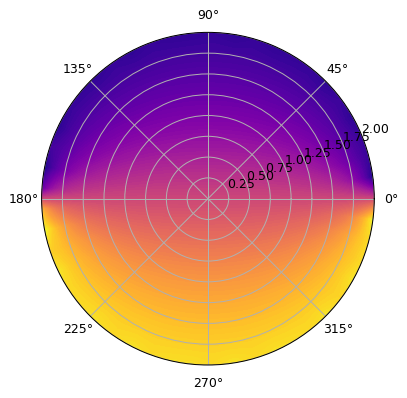

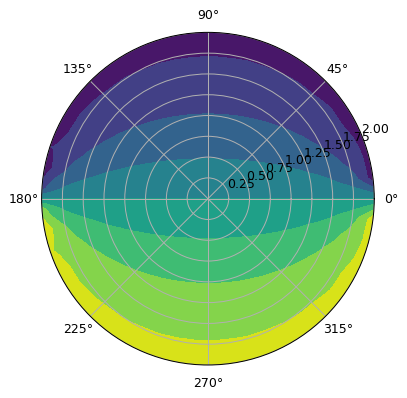

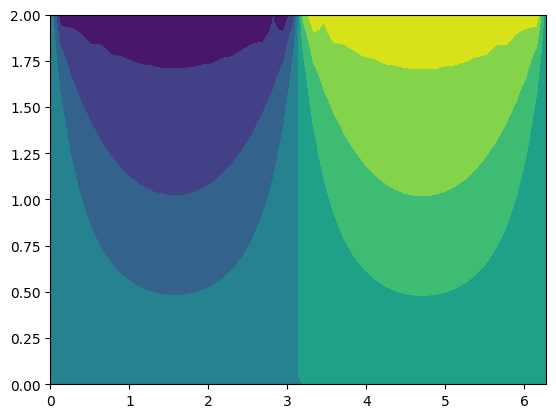

array([-1.89608854e-15, -1.14224685e+00, -9.70687742e-01, -9.77346969e-01,
       -1.04693026e+00, -9.48203139e-01, -1.04237441e+00, -9.75997894e-01,
       -1.00245543e+00, -1.01671912e+00, -9.70914477e-01, -1.03207803e+00,
       -9.74570429e-01, -1.01115955e+00, -1.00688686e+00, -9.76139174e-01,
       -1.03493103e+00, -9.63700201e-01, -1.02600766e+00, -9.95645123e-01,
       -9.73823744e-01, -1.06159361e+00, -9.01975015e-01, -1.13739757e+00,
       -7.45492229e-01,  7.45492229e-01,  1.13739757e+00,  9.01975015e-01,
        1.06159361e+00,  9.73823744e-01,  9.95645123e-01,  1.02600766e+00,
        9.63700201e-01,  1.03493103e+00,  9.76139174e-01,  1.00688686e+00,
        1.01115955e+00,  9.74570429e-01,  1.03207803e+00,  9.70914477e-01,
        1.01671912e+00,  1.00245543e+00,  9.75997894e-01,  1.04237441e+00,
        9.48203139e-01,  1.04693026e+00,  9.77346969e-01,  9.70687742e-01,
        1.14224685e+00,  1.89608854e-15])

In [320]:
#xs, ys = np.meshgrid(r, theta, sparse = True) # it all depends on how np is constructing this meshgrid 

zs = simulation(10)


# redefining axes not using np.meshgrid as it doesnt seem to matter
r = np.linspace(0, radius , D) 
theta = np.linspace(0, 2*np.pi , D)  #-np.pi, np.pi
#h = plt.contourf(theta, r, zs)
#plt.colorbar()
#plt.show()
plt.subplots( dpi = 90, subplot_kw=dict(projection = 'polar') )  # matplotlib constructing a plot where it takes polar arguments, converts them to cartesian and plots them 
#nicely on the interface, it takes the first value of r and the first theta for all values for theta then does the second r, which is why this works for my r by theta array U.
plt.contourf(theta, r, zs, 100, cmap = 'plasma') #100, before cmap
plt.show()

plt.subplots( dpi = 90, subplot_kw=dict(projection = 'polar') )   
plt.contourf(theta, r, zs)
plt.show()

plt.contourf(theta,r,zs)
plt.show()

zs[49, :]

## Euclidean norm & fourier visualisation

In [334]:

#[49,:] is the last circle of theta at max r 
zs[49,:].round(2) # and zs[49,]

array([-0.  , -1.14, -0.97, -0.98, -1.05, -0.95, -1.04, -0.98, -1.  ,
       -1.02, -0.97, -1.03, -0.97, -1.01, -1.01, -0.98, -1.03, -0.96,
       -1.03, -1.  , -0.97, -1.06, -0.9 , -1.14, -0.75,  0.75,  1.14,
        0.9 ,  1.06,  0.97,  1.  ,  1.03,  0.96,  1.03,  0.98,  1.01,
        1.01,  0.97,  1.03,  0.97,  1.02,  1.  ,  0.98,  1.04,  0.95,
        1.05,  0.98,  0.97,  1.14,  0.  ])

In [326]:
# therefore were looking at boundary conditions of 

#zs[0,0:24] = -100 # for the 
#zs[0,24:49] = 100
periscope = zs.round(2)


np.set_printoptions(threshold=np.inf)
#periscope

In [327]:
periscope[49,:] # it looks like the top side is actually the cold side (if python truly is going anticlockwise)
# this is the rim of the cicle NOTICE!!! that the value of U jumps up and then down and then up and then down. This is because of the fourier approximation not being perfect.
# with a hight value of n this would likely be much less obvious very cool!!!!
#before saying that in the final thing make sure thats right

array([-0.  , -1.14, -0.97, -0.98, -1.05, -0.95, -1.04, -0.98, -1.  ,
       -1.02, -0.97, -1.03, -0.97, -1.01, -1.01, -0.98, -1.03, -0.96,
       -1.03, -1.  , -0.97, -1.06, -0.9 , -1.14, -0.75,  0.75,  1.14,
        0.9 ,  1.06,  0.97,  1.  ,  1.03,  0.96,  1.03,  0.98,  1.01,
        1.01,  0.97,  1.03,  0.97,  1.02,  1.  ,  0.98,  1.04,  0.95,
        1.05,  0.98,  0.97,  1.14,  0.  ])

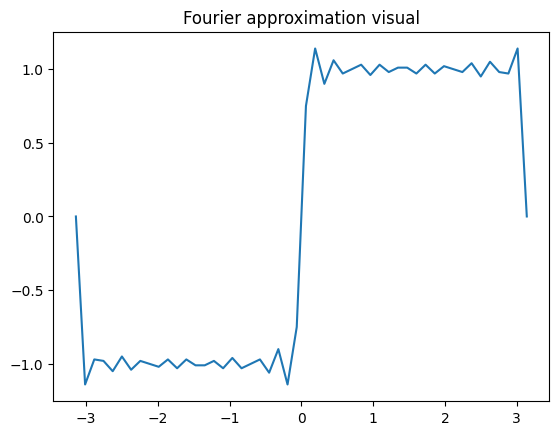

In [338]:
thetaplots = np.linspace(-np.pi, np.pi, D)
#y = np.linspace(0, 50, )
plotable =  periscope[D-1,:] # detaching slice from the D by D array 
#plt.show()

plotable.shape
plt.plot(thetaplots, plotable)
plt.title('Fourier approximation visual')
plt.show()

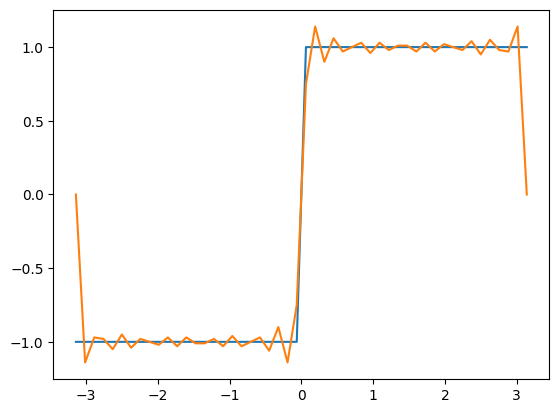

1.504393565527319


In [339]:
# for the Euclidean norm firstly I need a function f(theta[i]) - which is my accurate square wave 
# maybe I could use the np.linalg.norm from the summative 

ftheta = np.linspace(-np.pi, np.pi, D)
for i in range(D):
   if -np.pi <= ftheta[i] <= 0 :
            ftheta[i] = -1
   elif 0 <= ftheta[i] <= np.pi:
      ftheta[i] = 1

thetaplots = np.linspace(-np.pi, np.pi, D)
plt.plot(thetaplots, ftheta)
plt.plot(thetaplots, plotable)
plt.show()

norm = np.linalg.norm(ftheta - plotable)
print(norm)               # norm here is really high this could be because i have done it wrong or it could be due to the gibbs phenonoma
    

In [341]:
N_list = [ 10, 20 , 40 , 80 , 160]

norms = np.zeros(len(N_list))

for i in range(len(N_list)):
    A = simulation(N_list[i])
    slice = A[D-1, :]

    norms = np.linalg.norm(ftheta - slice)

print(norms)

nan


C:\Users\peter\AppData\Local\Temp\ipykernel_58460\1610344472.py:28: RuntimeWarning: divide by zero encountered in divide
  U[ :,j] += (  (r)**(2*(n[i])-1) * 4 * u * np.sin((2*(n[i])-1)* theta[j])  )/ (  (2*(n[i])-1) * np.pi * a**(2*(n[i])-1)  )
C:\Users\peter\AppData\Local\Temp\ipykernel_58460\1610344472.py:28: RuntimeWarning: invalid value encountered in divide
  U[ :,j] += (  (r)**(2*(n[i])-1) * 4 * u * np.sin((2*(n[i])-1)* theta[j])  )/ (  (2*(n[i])-1) * np.pi * a**(2*(n[i])-1)  )
C:\Users\peter\AppData\Local\Temp\ipykernel_58460\1610344472.py:28: RuntimeWarning: invalid value encountered in add
  U[ :,j] += (  (r)**(2*(n[i])-1) * 4 * u * np.sin((2*(n[i])-1)* theta[j])  )/ (  (2*(n[i])-1) * np.pi * a**(2*(n[i])-1)  )


## Numerical solution 

### Without the 1/r and 1/r^2 terms (Incorrect for polar)

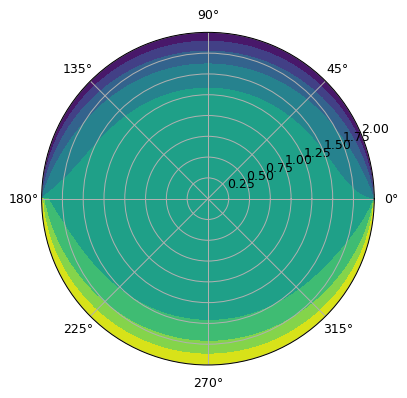

In [ ]:
max_iters = 500

length_r = 100
length_theta = 100

radius = 2


the_top_temp = 100
the_bot_temp = -100
r_zero = 0

filler_value = 10


#r, theta = np.meshgrid(np.arange(0, length_r), np.arange(0,length_theta))  

r = np.linspace(0, radius , length_r)  # slices of radius of whatever length_r is set to
theta = np.linspace(-np.pi, np.pi , length_theta) # slices of -pi to pi of length_theta 

#r, theta = np.meshgrid(np.linspace(0, radius , length_r), np.linspace(-np.pi, np.pi , length_theta) )


u = np.empty((length_r, length_theta))
u.fill(filler_value)

# DOING ALL THE BOUNDARY CONDITIONS BY ARRAY SLICING 
u[length_r-1, (length_r//2): length_r] = the_bot_temp         # issue with / returning a floating point, not an integer, for indexing integers are required
u[length_r-1, 0: (length_r//2)] = the_top_temp             # this is done as python places polar arrays counter clockwise 
u[0, :] = r_zero


for iteration in range(max_iters):
    for i in range(1, (length_r -1)): # need to skip over boundary points that we have defined to avoid iterating over them. 
        for j in range(length_theta-1): #(1, (length_theta -1)):
            u[i,j] = 0.25* (u[i+1,j] + u[i-1,j] + u[i,j+1] + u[i,j-1])   # this is the formular for the cartesian not polar h here is 1 so h^2 = 1 hence stuff/1 = stuff



#plt.contourf(theta,r , u)
#plt.show()

plt.subplots(dpi = 90 , subplot_kw=dict(projection = 'polar'))     # maybe the tightening side needs to be on the x axis  thats why this works 
plt.contourf(theta, r ,u)   
plt.show()


In [ ]:
# I STILL THINK THIS ITTERATION IS INCORRECT AS IT DOES NOT LOOK LIKE THE FOURIER TRANSFORM< the iteration does not account for the 1/r and 1/r^2 terms in the laplacian 
#jobs to do
# get your arrays straight, figure out why it is plotting weirdly, and not taking inputs in r,theta format always 
#figure out the iteratve formula not accounting for the polar domain and 1/r & 1/r^2 terms in the laplacian, or just the general squeezing of the coordinate system./////
# fix the fact that the hot and the colds are the wrong way round for your analytical solution. MASSIVE PROBLEM

### With the 1/r and 1/r^2 terms (correct numerical solution)

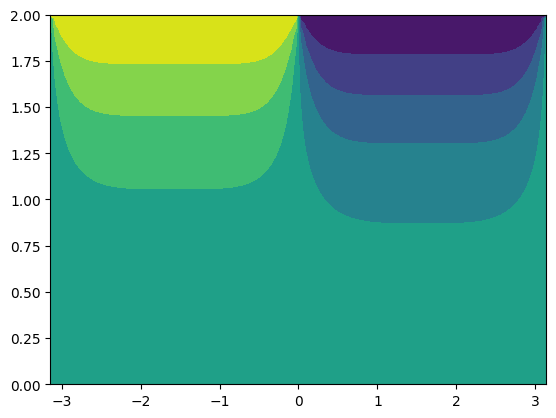

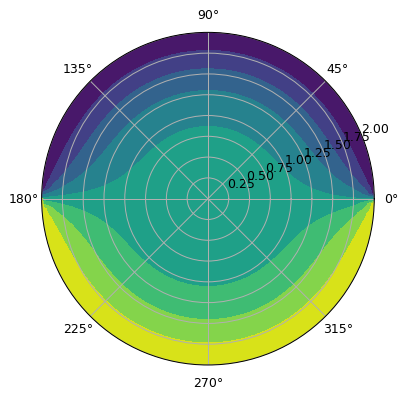

0.01578814480698274
0.0001989187837890479


In [ ]:
max_iters = 500

length_r = 100
length_theta = 100

radius = 2



the_top_temp = 100
the_bot_temp = -100
r_zero = 0

filler_value = 10


#r, theta = np.meshgrid(np.arange(0, length_r), np.arange(0,length_theta))  

r = np.linspace(0, radius , length_r)  # slices of radius of whatever length_r is set to
theta = np.linspace(-np.pi, np.pi , length_theta) # slices of -pi to pi of length_theta 

#r, theta = np.meshgrid(np.linspace(0, radius , length_r), np.linspace(-np.pi, np.pi , length_theta) )


u = np.empty((length_r, length_theta))
u.fill(filler_value)

# DOING ALL THE BOUNDARY CONDITIONS BY ARRAY SLICING 
u[length_r-1, 0: (length_r//2)] = the_top_temp             # this is done as python places polar arrays counter clockwise 
u[length_r-1, (length_r//2): length_r] = the_bot_temp         # issue with / returning a floating point, not an integer, for indexing integers are required
u[0, :] = r_zero

#/////////////////////////////////////////Definintions of polar laplace terms 
#del_r_squ = (radius/length_r)**2                             # (2/100)**2 = 0.0004
#del_theta_squ =  ((2*np.pi) / length_theta)**2               # (6.3/100) = 0.0063
#r_squ = radius**2                                            # (2**2)    = 4 
#use radius for r                                            # 2         = 2 
#two_del_r = 2*(radius/length_r)                              #  2*(2/100)= 0.04

#multiplier = (del_r_squ*r_squ*del_theta_squ) / (2*(r_squ*del_theta_squ)) + 2*(del_r_squ)

#multiplier = ((r[i] - r[i-1])**2)* ((r[i])**2) * ((theta[j] - theta[j-1])**2) / (2*(((r[i])**2) * (theta[j] - theta[j-1])**2)) # MAIN BUG FOUND why have you left out the 2delta r bit 
#///////////////////////////////////////////
for iteration in range(max_iters):
    for i in range(1, (length_r -1)): # need to skip over boundary points that we have defined to avoid iterating over them.
        
        X = (r[i] - r[i-1])**2  # delta radius(i) squared                 # CHANGE IN R is just r2 -r1
        Y = (r[i] * (2*(r[i] - r[i-1])))          # radius(i) times 2 times delta r     
    

        for j in range(1, length_theta-1): #(1, (length_theta -1)):

            Z = ((r[i])**2 )*((theta[j] - theta[j-1])**2)  # 
            multiplier = ((r[i] - r[i-1])**2)* ((r[i])**2) * ((theta[j] - theta[j-1])**2) / ( (2*(((r[i])**2) * (theta[j] - theta[j-1])**2)) + 2*((r[i] - r[i -1])**2) )

            u[i,j] =  (multiplier) *( (u[i-1,j]/ X) + (u[i+1,j]/ X) + (u[i+1,j]/ Y) + (-u[i-1,j]/ Y) + (u[i,j-1]/ Z) + (u[i,j+1]/ Z) ) #(multiplier) *



#  u[i,j] = ((del_r_squ*r_squ*del_theta_squ) / (2*(r_squ*del_theta_squ)) + 2*(del_r_squ) ) * ( (u[i-1,j]/ del_r_squ) + (u[i+1,j]/del_r_squ) + (u[i+1,j]/(radius*two_del_r)) + (-u[i-1,j]/(radius*two_del_r)) + (u[i,j-1]/(r_squ*del_theta_squ)) + (u[i,j+1]/(r_squ*del_theta_squ)) )

plt.contourf(theta,r , u)
plt.show()

plt.subplots(dpi = 90 , subplot_kw=dict(projection = 'polar'))     # maybe the tightening side needs to be on the x axis  thats why this works because It folds on theta
plt.contourf(theta, r ,u)   
plt.show()



print(Z)
print(multiplier)
#this may be because r is not a static value and it varies at that point in the discretisation. so i have to change my code 

#I think im itterating over one of the boudaries here / fixed 

In [262]:
u[length_r-1, :]

array([ 100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,
        100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,
        100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,
        100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,
        100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,  100.,
        100.,  100.,  100.,  100.,  100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100., -100., -100., -100., -100., -100., -100., -100., -100.,
       -100.])